🚗 Vehicle Sensor Anomaly Detection

Objective:
Detect abnormal sensor values over time.

Approach:
Time-series analysis
Statistical thresholding

Result:
Successfully identified anomalies in sensor data

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/ambient_temperature_system_failure.csv"
df = pd.read_csv(url)

df.head()

,timestamp,value
0,2013-07-04 00:00:00,69.880835
1,2013-07-04 01:00:00,71.220227
2,2013-07-04 02:00:00,70.877805
3,2013-07-04 03:00:00,68.959400
4,2013-07-04 04:00:00,69.283551


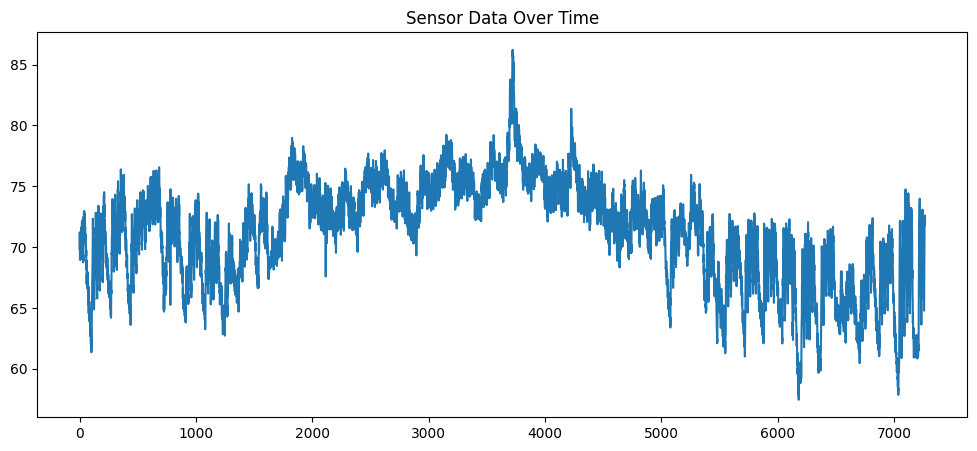

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['value'])
plt.title("Sensor Data Over Time")
plt.show()

In [3]:
mean = df['value'].mean()
std = df['value'].std()

threshold_upper = mean + 2*std
threshold_lower = mean - 2*std

df['anomaly'] = ((df['value'] > threshold_upper) | (df['value'] < threshold_lower)).astype(int)

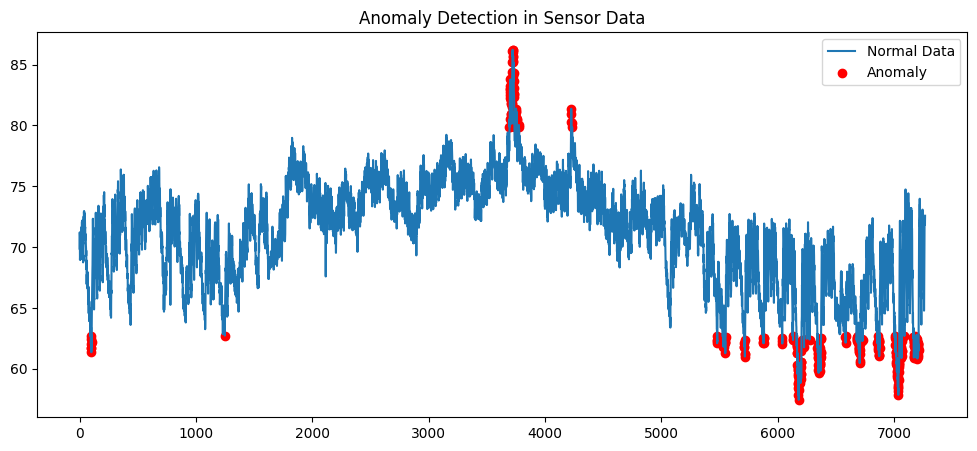

In [4]:
plt.figure(figsize=(12,5))
plt.plot(df['value'], label='Normal Data')
plt.scatter(df[df['anomaly']==1].index, df[df['anomaly']==1]['value'], color='red', label='Anomaly')
plt.legend()
plt.title("Anomaly Detection in Sensor Data")
plt.show()